# 02 Cleaning, Preprocessing, and EDA

## Purpose
Record the cleaning and feature preparation steps applied to the dataset, then use exploratory analysis to understand distributions, missingness, and patterns relevant to prediction.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def print_section(title: str) -> None:
    print(f"\n{'=' * 12} {title} {'=' * 12}")


In [2]:
DATA_PATH = Path("Data/raw/noshows.csv")
INTERIM_PATH = Path("Data/interim/cleaned_dataset.csv")
TARGET_COLUMN = "No-show"

raw_df = pd.read_csv(DATA_PATH).drop_duplicates().copy()

scheduled_dt = pd.to_datetime(raw_df["ScheduledDay"], errors="coerce", utc=True)
appointment_dt = pd.to_datetime(raw_df["AppointmentDay"], errors="coerce", utc=True)
lead_time_days = (appointment_dt - scheduled_dt).dt.total_seconds().div(24 * 60 * 60)

df = raw_df.copy()
df["Age"] = df["Age"].clip(lower=0)
df["lead_time_days"] = lead_time_days.clip(lower=0).fillna(0)
df["scheduled_hour"] = scheduled_dt.dt.hour.fillna(0).astype(int)
df["scheduled_weekday"] = scheduled_dt.dt.day_name().fillna("Unknown")
df["appointment_weekday"] = appointment_dt.dt.day_name().fillna("Unknown")
df["appointment_month"] = appointment_dt.dt.month.fillna(0).astype(int)
df["same_day_appointment"] = (df["lead_time_days"] < 1).astype(int)
df["long_wait_30_plus"] = (df["lead_time_days"] >= 30).astype(int)
df["age_group"] = pd.cut(
    df["Age"],
    bins=[-1, 17, 34, 49, 64, 200],
    labels=["child", "young_adult", "adult", "mid_older", "older"],
)
df[TARGET_COLUMN] = df[TARGET_COLUMN].map({"No": 0, "Yes": 1}).astype(int)
df = df.drop(columns=["PatientId", "AppointmentID", "ScheduledDay", "AppointmentDay"])

df.head()


,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,lead_time_days,scheduled_hour,scheduled_weekday,appointment_weekday,appointment_month,same_day_appointment,long_wait_30_plus,age_group
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0.0,18,Friday,Friday,4,1,0,mid_older
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0.0,16,Friday,Friday,4,1,0,mid_older
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,0,0.0,16,Friday,Friday,4,1,0,mid_older
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,0.0,17,Friday,Friday,4,1,0,child
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0.0,16,Friday,Friday,4,1,0,mid_older


## Cleaning Decisions
- The cleaned dataset removes raw identifiers and converts scheduling timestamps into operational features such as lead time, scheduled hour, weekday, and appointment month.
- Two simple operational flags were added for same-day scheduling and long waits of 30 or more days because they are easy to explain to clinic stakeholders.
- The target was recoded from `Yes` and `No` into a binary outcome so model evaluation can be handled consistently across sklearn workflows.
- Negative ages were clipped at zero and raw date columns were dropped after feature engineering to keep the modeling table compact and deployment-oriented.

In [3]:
print_section("Missing Values")
display(df.isna().sum().sort_values(ascending=False).head(20))

print_section("Basic Descriptives")
display(df.describe(include="all").T.head(20))


============ Missing Values ============

============ Basic Descriptives ============


Gender                  0
Age                     0
long_wait_30_plus       0
same_day_appointment    0
appointment_month       0
appointment_weekday     0
scheduled_weekday       0
scheduled_hour          0
lead_time_days          0
No-show                 0
SMS_received            0
Handcap                 0
Alcoholism              0
Diabetes                0
Hipertension            0
Scholarship             0
Neighbourhood           0
age_group               0
dtype: int64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,110527,2,F,71840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,110527.0,NaN,NaN,NaN,37.088883,23.11019,0.0,18.0,37.0,55.0,115.0
Neighbourhood,110527,81,JARDIM CAMBURI,7717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Scholarship,110527.0,NaN,NaN,NaN,0.098266,0.297675,0.0,0.0,0.0,0.0,1.0
Hipertension,110527.0,NaN,NaN,NaN,0.197246,0.397921,0.0,0.0,0.0,0.0,1.0
Diabetes,110527.0,NaN,NaN,NaN,0.071865,0.258265,0.0,0.0,0.0,0.0,1.0
Alcoholism,110527.0,NaN,NaN,NaN,0.0304,0.171686,0.0,0.0,0.0,0.0,1.0
Handcap,110527.0,NaN,NaN,NaN,0.022248,0.161543,0.0,0.0,0.0,0.0,4.0
SMS_received,110527.0,NaN,NaN,NaN,0.321026,0.466873,0.0,0.0,0.0,1.0,1.0
No-show,110527.0,NaN,NaN,NaN,0.201933,0.401444,0.0,0.0,0.0,0.0,1.0


In [4]:
print_section("Target Confirmation")
display(df[TARGET_COLUMN].value_counts(dropna=False))

feature_df = df.drop(columns=[TARGET_COLUMN])
categorical_features = feature_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_features = [column for column in feature_df.columns if column not in categorical_features]

display(pd.Series(categorical_features, name="categorical_feature"))
display(pd.Series(numeric_features, name="numeric_feature"))
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")



============ Target Confirmation ============
Numeric features: 12
Categorical features: 5


No-show
0    88208
1    22319
Name: count, dtype: int64

0                 Gender
1          Neighbourhood
2      scheduled_weekday
3    appointment_weekday
4              age_group
Name: categorical_feature, dtype: object

0                      Age
1              Scholarship
2             Hipertension
3                 Diabetes
4               Alcoholism
5                  Handcap
6             SMS_received
7           lead_time_days
8           scheduled_hour
9        appointment_month
10    same_day_appointment
11       long_wait_30_plus
Name: numeric_feature, dtype: object


============ Exploratory Data Analysis ============


<cell>:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<cell>:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<cell>:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<cell>:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


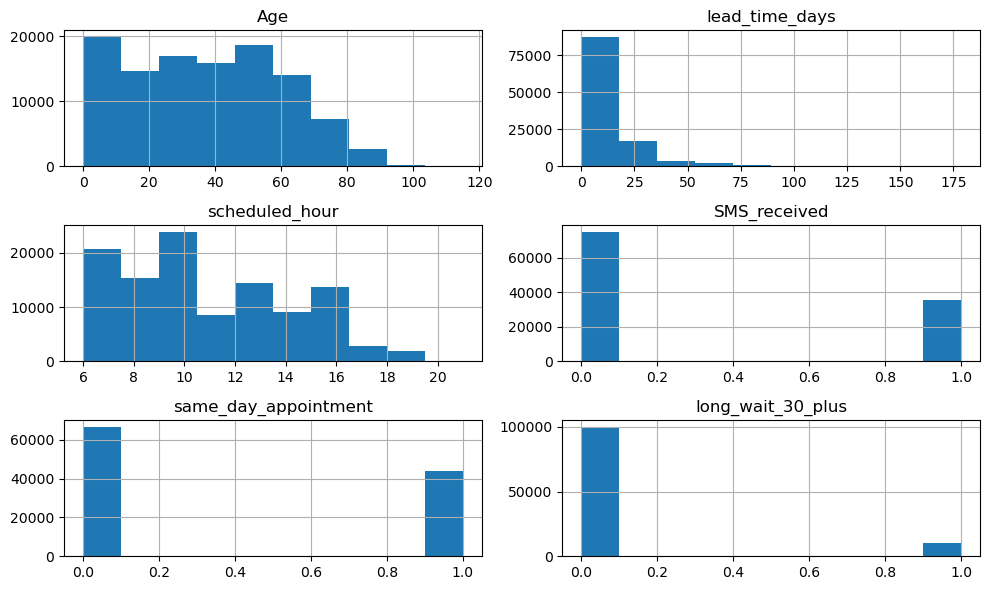

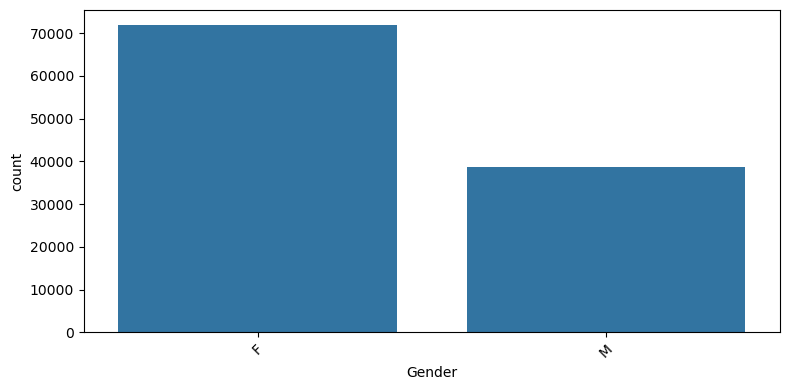

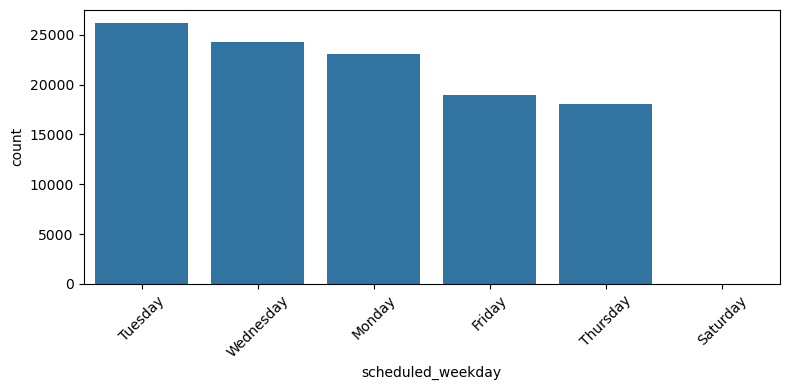

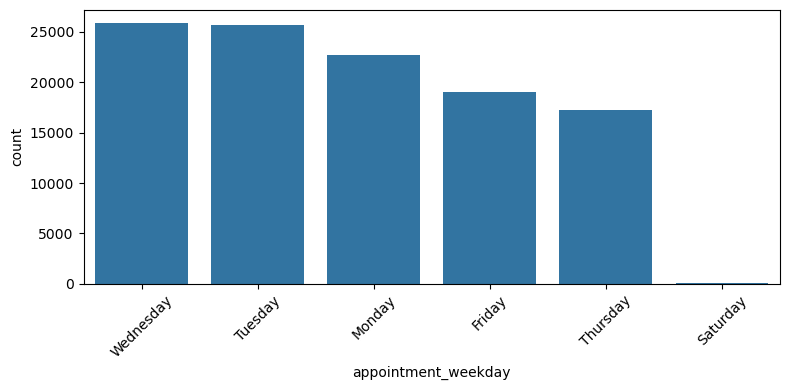

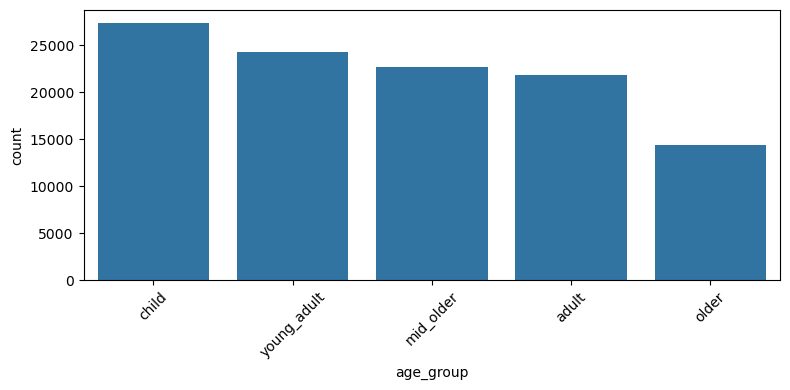

In [5]:
print_section("Exploratory Data Analysis")
candidate_numeric = [column for column in ["Age", "lead_time_days", "scheduled_hour", "SMS_received", "same_day_appointment", "long_wait_30_plus"] if column in df.columns]
if candidate_numeric:
    df[candidate_numeric].hist(figsize=(10, 6))
    plt.tight_layout()

candidate_categorical = [column for column in ["Gender", "scheduled_weekday", "appointment_weekday", "age_group", "Neighbourhood"] if column in categorical_features][:4]
for column in candidate_categorical:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=column, order=df[column].value_counts().index[:10])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Feature Preparation Plan
- The final feature set mixes simple numeric indicators with a small number of categorical fields, which is manageable for a transparent baseline model.
- `Neighbourhood`, `Gender`, weekday features, and the added age group capture context that may proxy for access barriers, while lead time and scheduling flags capture modifiable scheduling behavior.
- Preprocessing remains inside the sklearn pipeline so imputation, encoding, and scaling are learned only on training data during validation.

In [6]:
INTERIM_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(INTERIM_PATH, index=False)
print(f"Saved interim dataset to: {INTERIM_PATH}")


Saved interim dataset to: Data\interim\cleaned_dataset.csv


## Takeaway Summary
This notebook converts the raw appointment table into a modeling-ready dataset centered on information available before the visit. The resulting feature set is much better aligned with a real outreach workflow because it emphasizes scheduling context instead of record identifiers. Those decisions make the later model easier to interpret and more credible for operational use.